# Phase 2 v4 — Municipal, Region, Island Analysis + Scenario Forecasting

This notebook extends Phase 2 to support:

1. **Municipal analysis**
2. **Regional analysis**
3. **Entire island analysis**
4. **Event-study style descriptive analysis**
5. **Scenario forecasting** for hypothetical hurricane categories or earthquake magnitudes
6. **Centralized outputs folder**

It is designed to work with the rebuilt Phase 1 panel and to degrade gracefully when some optional columns are missing.


In [1]:

import os, json, warnings, math
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("phase2_outputs_v4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
    "../processed_puerto_rico_data_rebuild.csv",
    "../processed_puerto_rico_data_enriched.csv",
]

data_path = None
for p in DATA_CANDIDATES:
    if Path(p).exists():
        data_path = Path(p)
        break

if data_path is None:
    raise FileNotFoundError(f"Could not find panel data in: {DATA_CANDIDATES}")

df = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)


def save_csv(df_obj, filename):
    path = OUTPUT_DIR / filename
    df_obj.to_csv(path, index=False)
    print(f"Saved: {path.resolve()}")
    return path

def save_json(obj, filename):
    path = OUTPUT_DIR / filename
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"Saved: {path.resolve()}")
    return path

saved_files = []

Loaded: processed_puerto_rico_data_rebuild.csv
Shape: (1170, 160)


In [2]:

region_map = {
    # Metro
    "San Juan": "Metro", "Bayamón": "Metro", "Carolina": "Metro", "Cataño": "Metro",
    "Guaynabo": "Metro", "Toa Alta": "Metro", "Toa Baja": "Metro", "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North", "Barceloneta": "North", "Camuy": "North", "Dorado": "North",
    "Florida": "North", "Hatillo": "North", "Manatí": "North", "Quebradillas": "North",
    "Vega Alta": "North", "Vega Baja": "North",

    # South
    "Arroyo": "South", "Coamo": "South", "Guayama": "South", "Guayanilla": "South",
    "Juana Díaz": "South", "Patillas": "South", "Peñuelas": "South", "Ponce": "South",
    "Salinas": "South", "Santa Isabel": "South", "Villalba": "South", "Yauco": "South",

    # West
    "Aguada": "West", "Aguadilla": "West", "Añasco": "West", "Cabo Rojo": "West",
    "Guánica": "West", "Hormigueros": "West", "Isabela": "West", "Lajas": "West",
    "Las Marías": "West", "Maricao": "West", "Mayagüez": "West", "Moca": "West",
    "Rincón": "West", "Sabana Grande": "West", "San Germán": "West", "San Sebastián": "West",

    # East
    "Canóvanas": "East", "Ceiba": "East", "Fajardo": "East", "Humacao": "East",
    "Juncos": "East", "Las Piedras": "East", "Loíza": "East", "Luquillo": "East",
    "Maunabo": "East", "Naguabo": "East", "Río Grande": "East", "San Lorenzo": "East",
    "Yabucoa": "East", "Caguas": "East", "Gurabo": "East", "Culebra": "East", "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains", "Aguas Buenas": "Central Mountains", "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains", "Cayey": "Central Mountains", "Ciales": "Central Mountains",
    "Cidra": "Central Mountains", "Comerío": "Central Mountains", "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains", "Lares": "Central Mountains", "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains", "Orocovis": "Central Mountains", "Utuado": "Central Mountains",
}

df["region"] = df["municipio"].map(region_map).fillna("Unassigned")
print(df["region"].value_counts(dropna=False))


region
East                 255
West                 240
Central Mountains    225
South                180
North                150
Metro                120
Name: count, dtype: int64


In [3]:

def first_existing(candidates, frame=df):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

col_population = first_existing(["total_population", "population"])
col_target = first_existing(["target_pop_change_3y_avg", "target_pop_change_2y_avg", "target_pop_change_1y"])
col_svi = first_existing(["svi_pca_1", "baseline_svi_pca_1", "baseline_vulnerability_index", "vulnerability_index"])
col_wind = first_existing(["wind_3yr_sum", "lag_wind_exposure_score_100km", "max_wind_knots"])
col_seis = first_existing(["seismic_3yr_sum", "lag_seismic_exposure_score_50km", "max_seismic_mag"])
col_hurr_x_svi = first_existing(["wind_3yr_x_svi", "hurricane_x_svi"])
col_quake_x_svi = first_existing(["seismic_3yr_x_svi", "earthquake_x_svi"])
col_income_growth = first_existing(["income_growth", "income_growth_3yr_avg"])
col_est_growth = first_existing(["establishment_growth", "lag_establishment_growth", "establishment_count"])
col_crime = first_existing(["lag_total_crime_rate", "total_crime_rate"])

resolved = {
    "population": col_population,
    "target": col_target,
    "svi": col_svi,
    "wind": col_wind,
    "seismic": col_seis,
    "wind_x_svi": col_hurr_x_svi,
    "seis_x_svi": col_quake_x_svi,
    "income_growth": col_income_growth,
    "est_growth": col_est_growth,
    "crime": col_crime,
}
resolved


{'population': 'total_population',
 'target': 'target_pop_change_3y_avg',
 'svi': 'svi_pca_1',
 'wind': 'wind_3yr_sum',
 'seismic': 'seismic_3yr_sum',
 'wind_x_svi': 'wind_3yr_x_svi',
 'seis_x_svi': 'seismic_3yr_x_svi',
 'income_growth': 'income_growth',
 'est_growth': 'establishment_growth',
 'crime': 'lag_total_crime_rate'}

## Descriptive analysis tables

These outputs support the narrative:

- Here is population change, vulnerability, hurricanes, and earthquakes since 2010
- At municipal, regional, and island levels
- Before and after shocks


In [4]:

metric_cols = [c for c in [
    resolved["population"], resolved["target"], resolved["svi"], resolved["wind"], resolved["seismic"],
    resolved["wind_x_svi"], resolved["seis_x_svi"], resolved["income_growth"], resolved["est_growth"], resolved["crime"]
] if c is not None]

municipal_latest = (
    df.sort_values(["municipio", "year"])
      .groupby("municipio", as_index=False)
      .tail(1)[["municipio", "region", "year"] + metric_cols]
      .sort_values(["region", "municipio"])
)

region_year = (
    df.groupby(["region", "year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)

island_year = (
    df.groupby(["year"], as_index=False)[metric_cols]
      .mean(numeric_only=True)
)
island_year["region"] = "Puerto Rico"

saved_files.append(str(save_csv(municipal_latest, "municipal_latest_snapshot.csv")))
saved_files.append(str(save_csv(region_year, "region_year_summary.csv")))
saved_files.append(str(save_csv(island_year, "island_year_summary.csv")))

print("Saved descriptive summaries to", OUTPUT_DIR)
municipal_latest.head()


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/municipal_latest_snapshot.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/region_year_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/island_year_summary.csv
Saved descriptive summaries to phase2_outputs_v4


,municipio,region,year,total_population,target_pop_change_3y_avg,svi_pca_1,wind_3yr_sum,seismic_3yr_sum,wind_3yr_x_svi,seismic_3yr_x_svi,income_growth,establishment_growth,lag_total_crime_rate
14,Adjuntas,Central Mountains,2024,17960.0,NaN,NaN,4.973126,98287.824739,18.710486,369790.156448,9.391400,NaN,100.139082
59,Aguas Buenas,Central Mountains,2024,23614.0,NaN,NaN,2.961816,47341.651881,8.106970,129581.780127,7.419301,NaN,71.165439
74,Aibonito,Central Mountains,2024,24636.0,NaN,NaN,3.142504,56348.106850,8.820083,158152.554087,4.252832,NaN,77.204388
149,Barranquitas,Central Mountains,2024,29054.0,NaN,NaN,3.150477,58294.740677,13.025665,241019.941799,9.932738,NaN,96.605023
269,Cayey,Central Mountains,2024,40917.0,NaN,NaN,3.012615,51112.542988,6.629618,112479.228034,10.210463,NaN,109.141180


In [5]:

# Event-study style summaries: compare periods with stronger hazard burden
tmp = df.copy()

if resolved["svi"] is not None:
    tmp["svi_group"] = pd.qcut(tmp[resolved["svi"]].rank(method="first"), 4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"])

event_summary = []
for hazard_name, hazard_col in [("hurricane", resolved["wind"]), ("earthquake", resolved["seismic"])]:
    if hazard_col is None or resolved["target"] is None:
        continue
    threshold = tmp[hazard_col].quantile(0.75)
    tmp[f"{hazard_name}_high"] = (tmp[hazard_col] >= threshold).astype(int)

    grp = (
        tmp.groupby([f"{hazard_name}_high", "region"], as_index=False)[[resolved["target"], resolved["svi"]]]
           .mean(numeric_only=True)
    )
    grp["hazard"] = hazard_name
    grp["threshold_used"] = threshold
    event_summary.append(grp)

    if "svi_group" in tmp.columns:
        grp2 = (
            tmp.groupby([f"{hazard_name}_high", "svi_group"], as_index=False)[[resolved["target"], resolved["svi"]]]
               .mean(numeric_only=True)
        )
        grp2["hazard"] = hazard_name
        grp2["threshold_used"] = threshold
        saved_files.append(str(save_csv(grp2, f"{hazard_name}_by_svi_group_summary.csv")))

event_summary_df = pd.concat(event_summary, ignore_index=True) if event_summary else pd.DataFrame()
saved_files.append(str(save_csv(event_summary_df, "event_study_region_summary.csv")))
event_summary_df.head(12)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/hurricane_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/earthquake_by_svi_group_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/event_study_region_summary.csv


,hurricane_high,region,target_pop_change_3y_avg,svi_pca_1,hazard,threshold_used,earthquake_high
0,0.0,Central Mountains,-0.942186,1.093256,hurricane,7.046256,NaN
1,0.0,East,-1.342352,-0.095236,hurricane,7.046256,NaN
2,0.0,Metro,-1.249240,-2.155443,hurricane,7.046256,NaN
3,0.0,North,-0.777883,-0.021532,hurricane,7.046256,NaN
4,0.0,South,-1.467870,0.873182,hurricane,7.046256,NaN
5,0.0,West,-1.116644,0.448364,hurricane,7.046256,NaN
6,1.0,Central Mountains,-0.670669,0.463026,hurricane,7.046256,NaN
7,1.0,East,-1.275465,-0.161643,hurricane,7.046256,NaN
8,1.0,Metro,-1.065718,-2.838944,hurricane,7.046256,NaN
9,1.0,North,-0.849243,-0.620902,hurricane,7.046256,NaN


## Modeling setup

This section keeps the predictive task in Phase 2, but aligns it with your goals:

- municipal predictions
- region summaries
- island summary
- scenario forecasting for hypothetical hazards


In [6]:

# Basic time split
model_df = df.copy()

target_col = resolved["target"]
if target_col is None:
    raise ValueError("No target column found.")

# Conservative feature set that should exist in most rebuilt files
feature_candidates = [
    "lag_pop_change_1",
    "lag_pop_change_2",
    resolved["svi"],
    resolved["wind"],
    resolved["seismic"],
    resolved["wind_x_svi"],
    resolved["seis_x_svi"],
    resolved["income_growth"],
    resolved["est_growth"],
    resolved["crime"],
    "year",
]

feature_cols = [c for c in feature_candidates if c is not None and c in model_df.columns]
print("Using features:", feature_cols)

# Add municipality fixed effects for panel structure
X = model_df[feature_cols + ["municipio", "region"]].copy()
y = model_df[target_col].copy()

valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].copy()
model_df = model_df.loc[valid].copy()

train_mask = model_df["year"] <= 2018
val_mask = model_df["year"] == 2019
test_mask = model_df["year"] >= 2020

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

num_cols = [c for c in feature_cols if c in X.columns]
cat_cols = ["municipio", "region"]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe),
        ]), cat_cols),
    ],
    remainder="drop",
)

models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "ridge_fe": Ridge(alpha=3.0),
    "random_forest": RandomForestRegressor(
        n_estimators=600, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=700, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1
    ),
    "hist_gbm": HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.03, max_iter=400, random_state=42
    ),
}

try:
    from catboost import CatBoostRegressor
    models["catboost"] = CatBoostRegressor(
        iterations=500, learning_rate=0.03, depth=6, loss_function="RMSE",
        verbose=False, random_seed=42
    )
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

results = []
pred_rows = []
fitted_models = {}

for name, model in models.items():
    if name == "catboost":
        # CatBoost can consume categorical strings more naturally
        cat_features = [X_train.columns.get_loc(c) for c in cat_cols]
        X_train_cb = X_train.copy()
        X_val_cb = X_val.copy()
        X_test_cb = X_test.copy()
        for c in num_cols:
            med = pd.to_numeric(X_train_cb[c], errors="coerce").median()
            X_train_cb[c] = pd.to_numeric(X_train_cb[c], errors="coerce").fillna(med)
            X_val_cb[c] = pd.to_numeric(X_val_cb[c], errors="coerce").fillna(med)
            X_test_cb[c] = pd.to_numeric(X_test_cb[c], errors="coerce").fillna(med)
        model.fit(X_train_cb, y_train, cat_features=cat_features)
        val_pred = model.predict(X_val_cb)
        test_pred = model.predict(X_test_cb)
    else:
        pipe = Pipeline([("pre", pre), ("model", model)])
        pipe.fit(X_train, y_train)
        val_pred = pipe.predict(X_val)
        test_pred = pipe.predict(X_test)
        model = pipe

    fitted_models[name] = model

    row = {
        "model": name,
        "n_features": len(feature_cols),
        "features": ", ".join(feature_cols + cat_cols),
        "val_r2": r2_score(y_val, val_pred) if len(y_val) else np.nan,
        "test_r2": r2_score(y_test, test_pred) if len(y_test) else np.nan,
        "val_rmse": np.sqrt(mean_squared_error(y_val, val_pred)) if len(y_val) else np.nan,
        "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)) if len(y_test) else np.nan,
        "val_mae": mean_absolute_error(y_val, val_pred) if len(y_val) else np.nan,
        "test_mae": mean_absolute_error(y_test, test_pred) if len(y_test) else np.nan,
    }
    row["val_r2_sign"] = "positive" if pd.notna(row["val_r2"]) and row["val_r2"] > 0 else ("zero" if row["val_r2"] == 0 else "negative")
    row["test_r2_sign"] = "positive" if pd.notna(row["test_r2"]) and row["test_r2"] > 0 else ("zero" if row["test_r2"] == 0 else "negative")
    results.append(row)

    pred_part = model_df.loc[test_mask, ["municipio", "region", "year", target_col]].copy()
    pred_part["model"] = name
    pred_part["prediction"] = test_pred
    pred_rows.append(pred_part)

results_df = pd.DataFrame(results).sort_values(["test_r2", "val_r2"], ascending=False).reset_index(drop=True)
pred_df = pd.concat(pred_rows, ignore_index=True)

saved_files.append(str(save_csv(results_df, "phase2_v4_model_comparison.csv")))
saved_files.append(str(save_csv(pred_df, "phase2_v4_test_predictions_all_models.csv")))

best_summary = results_df.iloc[0].to_dict()
saved_files.append(str(save_json(best_summary, "phase2_v4_best_model_summary.json")))

display(results_df)


Using features: ['lag_pop_change_1', 'lag_pop_change_2', 'svi_pca_1', 'wind_3yr_sum', 'seismic_3yr_sum', 'wind_3yr_x_svi', 'seismic_3yr_x_svi', 'income_growth', 'establishment_growth', 'lag_total_crime_rate', 'year']
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_model_comparison.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_test_predictions_all_models.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_best_model_summary.json


,model,n_features,features,val_r2,test_r2,val_rmse,test_rmse,val_mae,test_mae,val_r2_sign,test_r2_sign
0,extra_trees,11,"lag_pop_change_1, lag_pop_change_2, svi_pca_1,...",0.407920,0.178581,1.365154,1.363072,1.090965,0.991510,positive,positive
1,random_forest,11,"lag_pop_change_1, lag_pop_change_2, svi_pca_1,...",0.209655,0.034764,1.577247,1.477587,1.251019,1.096640,positive,positive
2,hist_gbm,11,"lag_pop_change_1, lag_pop_change_2, svi_pca_1,...",0.182025,-0.026492,1.604580,1.523752,1.300809,1.143861,positive,negative
3,dummy_mean,11,"lag_pop_change_1, lag_pop_change_2, svi_pca_1,...",-0.089402,-0.245195,1.851763,1.678244,1.539942,1.276338,negative,negative
4,ridge_fe,11,"lag_pop_change_1, lag_pop_change_2, svi_pca_1,...",-0.266011,-7.242730,1.996227,4.317892,1.699700,3.632838,negative,negative


In [7]:

# Best model summary
best = results_df.iloc[0].to_dict()
saved_files.append(str(save_json(best, "phase2_v4_best_model_summary.json")))

best


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_best_model_summary.json


{'model': 'extra_trees',
 'n_features': 11,
 'features': 'lag_pop_change_1, lag_pop_change_2, svi_pca_1, wind_3yr_sum, seismic_3yr_sum, wind_3yr_x_svi, seismic_3yr_x_svi, income_growth, establishment_growth, lag_total_crime_rate, year, municipio, region',
 'val_r2': 0.4079199696004544,
 'test_r2': 0.17858057969069385,
 'val_rmse': 1.365153525554649,
 'test_rmse': 1.3630718660056826,
 'val_mae': 1.0909650131569562,
 'test_mae': 0.9915100301006046,
 'val_r2_sign': 'positive',
 'test_r2_sign': 'positive'}

## SHAP interpretation

This section belongs **immediately after model comparison and best-model selection**, because SHAP explains **how the fitted tree model made predictions** before moving into downstream summaries and scenario forecasting.

To keep the slide-ready outputs clean, the plots below exclude `year` from the main SHAP visualizations.


In [8]:
# =========================
# SHAP VISUALIZATION FOR EXTRA TREES
# (slide-ready version: excludes `year` from plots)
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor

# -------------------------
# 0. Check SHAP installation
# -------------------------
try:
    import shap
except ImportError as e:
    raise ImportError(
        "The 'shap' package is not installed in this environment. "
        "Install it first, then restart the kernel.\n"
        "Terminal: python -m pip install shap"
    ) from e

# -------------------------
# 1. Check required objects
# -------------------------
if "X_test" not in globals():
    raise ValueError(
        "X_test is not defined. Run the model training / evaluation cells first."
    )

if X_test is None or len(X_test) == 0:
    raise ValueError("X_test is empty, so SHAP plots cannot be generated.")

# -------------------------
# 2. Retrieve the fitted Extra Trees pipeline from Phase 2 modeling
# -------------------------
if "fitted_models" not in globals() or not isinstance(fitted_models, dict):
    raise ValueError(
        "fitted_models is not available. Run the Phase 2 modeling cell first."
    )

if "extra_trees" not in fitted_models:
    raise ValueError(
        "The fitted Extra Trees pipeline was not found in fitted_models. "
        "Run the modeling cell again before running SHAP."
    )

model_name = "extra_trees"
model_pipeline = fitted_models["extra_trees"]
print(f"Using fitted model pipeline: {model_name}")

# -------------------------
# 3. Identify preprocessing and estimator steps
# -------------------------
if not hasattr(model_pipeline, "named_steps"):
    raise ValueError(
        f"{model_name} is not a valid sklearn Pipeline with named_steps."
    )

preprocessor = None
estimator = None

for step_name, step_obj in model_pipeline.named_steps.items():
    if isinstance(step_obj, ExtraTreesRegressor):
        estimator = step_obj
    elif hasattr(step_obj, "transform") and hasattr(step_obj, "get_feature_names_out"):
        preprocessor = step_obj

if preprocessor is None:
    for step_name, step_obj in model_pipeline.named_steps.items():
        if step_obj is not estimator and hasattr(step_obj, "transform"):
            preprocessor = step_obj
            break

if estimator is None:
    raise ValueError("Could not find the Extra Trees estimator inside the pipeline.")

if preprocessor is None:
    raise ValueError("Could not find the preprocessing step inside the pipeline.")

# -------------------------
# 4. Prepare transformed SHAP sample
# -------------------------
max_shap_rows = 300
random_state = 42

X_shap_source = X_test.copy()

if len(X_shap_source) > max_shap_rows:
    X_shap_source = X_shap_source.sample(max_shap_rows, random_state=random_state)

X_shap = preprocessor.transform(X_shap_source)

if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

# -------------------------
# 5. Recover transformed feature names
# -------------------------
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = [f"feature_{i}" for i in range(X_shap.shape[1])]

clean_feature_names = []
for f in transformed_feature_names:
    f = str(f)
    f = f.replace("num__", "")
    f = f.replace("cat__", "")
    f = f.replace("remainder__", "")
    clean_feature_names.append(f)

X_shap_df = pd.DataFrame(X_shap, columns=clean_feature_names)

# -------------------------
# 6. Compute SHAP values
# -------------------------
explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_shap_df)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# -------------------------
# 7. Create output folder
# -------------------------
output_dir = "phase2_shap_outputs"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# 8. Build slide-ready subset (exclude year and one-off dummy columns if desired)
# -------------------------
exclude_exact = {"year"}

# Optional: drop one-hot municipio dummies from the main slide plot
# Set to False if you want to keep them
drop_municipio_dummies = True

plot_features = []
for c in X_shap_df.columns:
    if c in exclude_exact:
        continue
    if drop_municipio_dummies and c.startswith("municipio_"):
        continue
    plot_features.append(c)

if len(plot_features) == 0:
    raise ValueError("No features left to plot after exclusions.")

plot_idx = [X_shap_df.columns.get_loc(c) for c in plot_features]
X_plot_df = X_shap_df[plot_features].copy()
shap_plot_values = shap_values[:, plot_idx]

# -------------------------
# 9. SHAP beeswarm / summary plot (without year)
# -------------------------
plt.figure()
shap.summary_plot(
    shap_plot_values,
    X_plot_df,
    show=False,
    max_display=12
)
plt.title("SHAP Summary Plot — Extra Trees (excluding year)")
plt.tight_layout()
summary_path = os.path.join(output_dir, "phase2_shap_summary_extratrees_no_year.png")
plt.savefig(summary_path, dpi=300, bbox_inches="tight")
plt.close()

# -------------------------
# 10. SHAP bar plot (without year)
# -------------------------
plt.figure()
shap.summary_plot(
    shap_plot_values,
    X_plot_df,
    plot_type="bar",
    show=False,
    max_display=12
)
plt.title("SHAP Feature Importance — Extra Trees (excluding year)")
plt.tight_layout()
bar_path = os.path.join(output_dir, "phase2_shap_bar_extratrees_no_year.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.close()

# -------------------------
# 11. Dependence plots (exclude year)
# -------------------------
dependence_candidates = [
    "lag_pop_change_1",
    "lag_pop_change_2",
    "svi_pca_1",
    "wind_3yr_sum",
    "wind_3yr_x_svi",
    "seismic_3yr_sum",
    "seismic_3yr_x_svi",
    "income_growth",
    "establishment_growth",
    "lag_total_crime_rate",
]

generated_dependence = []

for feat in dependence_candidates:
    if feat in X_plot_df.columns:
        plt.figure()
        shap.dependence_plot(
            feat,
            shap_plot_values,
            X_plot_df,
            show=False,
            interaction_index=None
        )
        plt.title(f"SHAP Dependence — {feat}")
        plt.tight_layout()
        dep_path = os.path.join(output_dir, f"phase2_shap_dependence_{feat}.png")
        plt.savefig(dep_path, dpi=300, bbox_inches="tight")
        plt.close()
        generated_dependence.append(dep_path)

# -------------------------
# 12. Save slide-ready SHAP importance table (without year)
# -------------------------
mean_abs_shap = np.abs(shap_plot_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_plot_df.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

csv_path = os.path.join(output_dir, "phase2_shap_importance_extratrees_no_year.csv")
shap_importance_df.to_csv(csv_path, index=False)

# -------------------------
# 13. Optional: prettified labels for slide review
# -------------------------
label_map = {
    "lag_pop_change_1": "Lagged population change (t-1)",
    "lag_pop_change_2": "Lagged population change (t-2)",
    "svi_pca_1": "Social vulnerability (PCA)",
    "wind_3yr_sum": "3-year hurricane exposure",
    "wind_3yr_x_svi": "Hurricane × vulnerability",
    "seismic_3yr_sum": "3-year earthquake exposure",
    "seismic_3yr_x_svi": "Earthquake × vulnerability",
    "income_growth": "Income growth",
    "establishment_growth": "Establishment growth",
    "lag_total_crime_rate": "Lagged crime rate",
    "region_East": "Region: East",
    "region_South": "Region: South",
    "region_West": "Region: West",
    "region_North": "Region: North",
    "region_Metro": "Region: Metro",
    "region_Central Mountains": "Region: Central Mountains",
}

shap_importance_pretty = shap_importance_df.copy()
shap_importance_pretty["feature_pretty"] = (
    shap_importance_pretty["feature"].map(label_map).fillna(shap_importance_pretty["feature"])
)

pretty_csv_path = os.path.join(output_dir, "phase2_shap_importance_extratrees_no_year_pretty.csv")
shap_importance_pretty.to_csv(pretty_csv_path, index=False)

# -------------------------
# 14. Report outputs
# -------------------------
print("\nSaved SHAP outputs:")
print(" -", summary_path)
print(" -", bar_path)
print(" -", csv_path)
print(" -", pretty_csv_path)

if generated_dependence:
    print("\nSaved dependence plots:")
    for p in generated_dependence:
        print(" -", p)

for artifact_path in [summary_path, bar_path, csv_path, pretty_csv_path, *generated_dependence]:
    if artifact_path not in saved_files:
        saved_files.append(str(artifact_path))

display(shap_importance_pretty.head(12))

Using fitted model pipeline: extra_trees

Saved SHAP outputs:
 - phase2_shap_outputs/phase2_shap_summary_extratrees_no_year.png
 - phase2_shap_outputs/phase2_shap_bar_extratrees_no_year.png
 - phase2_shap_outputs/phase2_shap_importance_extratrees_no_year.csv
 - phase2_shap_outputs/phase2_shap_importance_extratrees_no_year_pretty.csv

Saved dependence plots:
 - phase2_shap_outputs/phase2_shap_dependence_lag_pop_change_1.png
 - phase2_shap_outputs/phase2_shap_dependence_lag_pop_change_2.png
 - phase2_shap_outputs/phase2_shap_dependence_svi_pca_1.png
 - phase2_shap_outputs/phase2_shap_dependence_wind_3yr_sum.png
 - phase2_shap_outputs/phase2_shap_dependence_wind_3yr_x_svi.png
 - phase2_shap_outputs/phase2_shap_dependence_seismic_3yr_sum.png
 - phase2_shap_outputs/phase2_shap_dependence_seismic_3yr_x_svi.png
 - phase2_shap_outputs/phase2_shap_dependence_income_growth.png
 - phase2_shap_outputs/phase2_shap_dependence_establishment_growth.png
 - phase2_shap_outputs/phase2_shap_dependence_lag

,feature,mean_abs_shap,feature_pretty
4,seismic_3yr_sum,0.137706,3-year earthquake exposure
14,region_South,0.106331,Region: South
11,region_East,0.102922,Region: East
0,lag_pop_change_1,0.092290,Lagged population change (t-1)
3,wind_3yr_sum,0.029416,3-year hurricane exposure
1,lag_pop_change_2,0.024223,Lagged population change (t-2)
6,seismic_3yr_x_svi,0.015915,Earthquake × vulnerability
13,region_North,0.015087,Region: North
8,establishment_growth,0.013631,Establishment growth
12,region_Metro,0.012993,Region: Metro


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Lead–lag analysis

This section adds a **lead–lag / tornado-style sensitivity view** for Phase 2. It tests whether key drivers matter most **contemporaneously (lag 0)** or with a **1–3 year delay**, using the same Extra Trees framework and the same Phase 2 time split.

The goal is not to replace the main model, but to visualize **when** shocks and structural variables are most informative for the target.

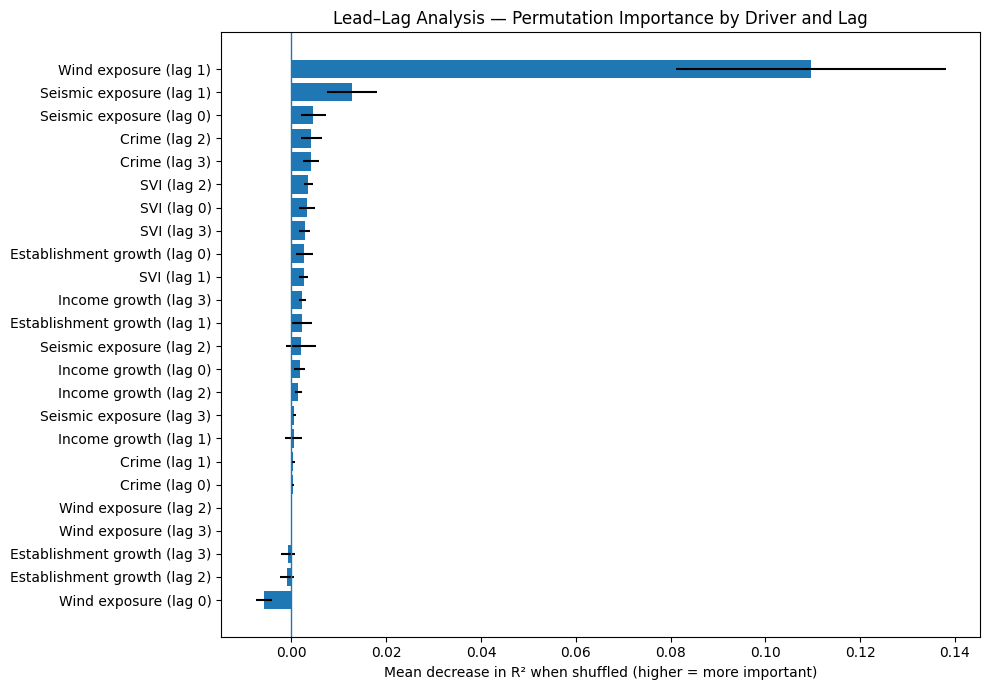

Lead–lag model summary:


,model,target,drivers_tested,lag_horizon,val_r2,test_r2,val_rmse,test_rmse,val_mae,test_mae
0,extra_trees_leadlag,target_pop_change_3y_avg,"wind_3yr_sum, seismic_3yr_sum, income_growth, ...","0,1,2,3",0.368286,0.08786,1.410106,1.436372,1.146129,1.105031


Top lagged effects:


,driver_label,lag,importance_mean,importance_std
1,Wind exposure,1,0.109630,0.028387
5,Seismic exposure,1,0.012754,0.005242
4,Seismic exposure,0,0.004614,0.002634
18,Crime,2,0.004226,0.002168
19,Crime,3,0.004220,0.001670
22,SVI,2,0.003584,0.000939
20,SVI,0,0.003317,0.001659
23,SVI,3,0.002783,0.001090
12,Establishment growth,0,0.002761,0.001799
21,SVI,1,0.002601,0.000971


In [9]:

# =========================================================
# LEAD–LAG ANALYSIS (tornado-style lag importance plot)
# =========================================================

from sklearn.inspection import permutation_importance

if "model_df" not in globals():
    raise ValueError("model_df is not defined. Run the main modeling setup cell first.")

if "target_col" not in globals() or target_col is None:
    raise ValueError("target_col is not defined. Run the main modeling setup cell first.")

if "train_mask" not in globals() or "val_mask" not in globals() or "test_mask" not in globals():
    raise ValueError("Time-split masks are not defined. Run the main modeling setup cell first.")

leadlag_df = model_df.copy().sort_values(["municipio", "year"]).reset_index(drop=True)

# Core drivers to test across lags
base_driver_candidates = [
    resolved.get("wind"),
    resolved.get("seismic"),
    resolved.get("income_growth"),
    resolved.get("est_growth"),
    resolved.get("crime"),
    resolved.get("svi"),
]

base_driver_candidates = [c for c in base_driver_candidates if c is not None and c in leadlag_df.columns]

if len(base_driver_candidates) == 0:
    raise ValueError("No eligible drivers found for lead–lag analysis.")

# Create 0..3 year lag versions within municipality
lag_horizon = [0, 1, 2, 3]
lag_feature_cols = []
for base_col in base_driver_candidates:
    for lag in lag_horizon:
        new_col = f"{base_col}_lag{lag}"
        if lag == 0:
            leadlag_df[new_col] = leadlag_df[base_col]
        else:
            leadlag_df[new_col] = leadlag_df.groupby("municipio")[base_col].shift(lag)
        lag_feature_cols.append(new_col)

# Keep the same core structural context used in the main Phase 2 model
context_cols = [c for c in ["lag_pop_change_1", "lag_pop_change_2", "year"] if c in leadlag_df.columns]
cat_cols_ll = [c for c in ["municipio", "region"] if c in leadlag_df.columns]

ll_feature_cols = lag_feature_cols + context_cols
ll_base_cols = list(dict.fromkeys(ll_feature_cols + cat_cols_ll + [target_col]))
ll_model_df = leadlag_df[ll_base_cols].copy()
ll_model_df["year"] = pd.to_numeric(ll_model_df["year"], errors="coerce")
ll_model_df = ll_model_df.dropna(subset=[target_col, "year"]).copy()

# Recreate Phase 2 split after lag construction
ll_train_mask = (ll_model_df["year"] <= 2018)
ll_val_mask   = (ll_model_df["year"] == 2019)
ll_test_mask  = (ll_model_df["year"] >= 2020)

X_ll = ll_model_df[ll_feature_cols + cat_cols_ll].copy()
y_ll = ll_model_df[target_col].copy()

X_ll_train, y_ll_train = X_ll.loc[ll_train_mask].copy(), y_ll.loc[ll_train_mask].copy()
X_ll_val,   y_ll_val   = X_ll.loc[ll_val_mask].copy(), y_ll.loc[ll_val_mask].copy()
X_ll_test,  y_ll_test  = X_ll.loc[ll_test_mask].copy(), y_ll.loc[ll_test_mask].copy()

num_cols_ll = [c for c in ll_feature_cols if c in X_ll.columns]

try:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe_ll = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre_ll = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols_ll),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", ohe_ll),
        ]), cat_cols_ll),
    ],
    remainder="drop",
)

leadlag_model = Pipeline([
    ("pre", pre_ll),
    ("model", ExtraTreesRegressor(
        n_estimators=700,
        max_depth=12,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
    ))
])

leadlag_model.fit(X_ll_train, y_ll_train)

ll_val_pred = leadlag_model.predict(X_ll_val)
ll_test_pred = leadlag_model.predict(X_ll_test)

leadlag_summary = pd.DataFrame([{
    "model": "extra_trees_leadlag",
    "target": target_col,
    "drivers_tested": ", ".join(base_driver_candidates),
    "lag_horizon": "0,1,2,3",
    "val_r2": r2_score(y_ll_val, ll_val_pred) if len(y_ll_val) else np.nan,
    "test_r2": r2_score(y_ll_test, ll_test_pred) if len(y_ll_test) else np.nan,
    "val_rmse": np.sqrt(mean_squared_error(y_ll_val, ll_val_pred)) if len(y_ll_val) else np.nan,
    "test_rmse": np.sqrt(mean_squared_error(y_ll_test, ll_test_pred)) if len(y_ll_test) else np.nan,
    "val_mae": mean_absolute_error(y_ll_val, ll_val_pred) if len(y_ll_val) else np.nan,
    "test_mae": mean_absolute_error(y_ll_test, ll_test_pred) if len(y_ll_test) else np.nan,
}])

# Permutation importance on the held-out test set for a tornado-style plot
perm = permutation_importance(
    leadlag_model,
    X_ll_test,
    y_ll_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# permutation_importance on a Pipeline returns one importance per ORIGINAL input column
ll_feature_names = list(X_ll_test.columns)
if len(ll_feature_names) != len(perm.importances_mean):
    ll_feature_names = [f"feature_{i}" for i in range(len(perm.importances_mean))]

perm_df = pd.DataFrame({
    "feature_raw": ll_feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
})

perm_df["feature"] = (
    perm_df["feature_raw"].astype(str)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

# Keep only the lag-driver rows for the tornado plot
lag_plot_df = perm_df[perm_df["feature"].str.contains(r"_lag[0-3]$", regex=True)].copy()
if lag_plot_df.empty:
    raise ValueError("No lag features found for the lead–lag tornado plot.")

lag_plot_df["base_driver"] = lag_plot_df["feature"].str.replace(r"_lag[0-3]$", "", regex=True)
lag_plot_df["lag"] = lag_plot_df["feature"].str.extract(r"_lag([0-3])$").astype(int)

# Create readable labels
nice_names = {
    resolved.get("wind"): "Wind exposure",
    resolved.get("seismic"): "Seismic exposure",
    resolved.get("income_growth"): "Income growth",
    resolved.get("est_growth"): "Establishment growth",
    resolved.get("crime"): "Crime",
    resolved.get("svi"): "SVI",
}
lag_plot_df["driver_label"] = lag_plot_df["base_driver"].map(nice_names).fillna(lag_plot_df["base_driver"])
lag_plot_df["plot_label"] = lag_plot_df["driver_label"] + " (lag " + lag_plot_df["lag"].astype(str) + ")"

# Save detailed CSV
leadlag_csv = OUTPUT_DIR / "phase2_v4_leadlag_importance.csv"
lag_plot_df.sort_values(["driver_label", "lag"]).to_csv(leadlag_csv, index=False)

leadlag_summary_csv = OUTPUT_DIR / "phase2_v4_leadlag_model_summary.csv"
leadlag_summary.to_csv(leadlag_summary_csv, index=False)

# Tornado-style horizontal bar plot
plot_df = lag_plot_df.sort_values("importance_mean", ascending=True).copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["plot_label"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.axvline(0, linewidth=1)
plt.title("Lead–Lag Analysis — Permutation Importance by Driver and Lag")
plt.xlabel("Mean decrease in R² when shuffled (higher = more important)")
plt.ylabel("")
plt.tight_layout()

leadlag_png = OUTPUT_DIR / "phase2_v4_leadlag_tornado.png"
plt.savefig(leadlag_png, dpi=180, bbox_inches="tight")
plt.show()

print("Lead–lag model summary:")
display(leadlag_summary)

print("Top lagged effects:")
display(
    lag_plot_df.sort_values("importance_mean", ascending=False)[
        ["driver_label", "lag", "importance_mean", "importance_std"]
    ].head(12)
)

if "saved_files" in globals() and isinstance(saved_files, list):
    saved_files.extend([str(leadlag_csv), str(leadlag_summary_csv), str(leadlag_png)])


## Municipal / region / island prediction summaries

These outputs let you explain predictions at all three levels.


In [10]:

best_model_name = results_df.iloc[0]["model"]
best_preds = pred_df[pred_df["model"] == best_model_name].copy()

municipal_pred_summary = (
    best_preds.groupby(["municipio", "region"], as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
    .sort_values(["region", "municipio"])
)

region_pred_summary = (
    best_preds.groupby("region", as_index=False)[[target_col, "prediction"]]
    .mean(numeric_only=True)
    .rename(columns={target_col: "actual_avg", "prediction": "predicted_avg"})
)

island_pred_summary = pd.DataFrame({
    "geography": ["Puerto Rico"],
    "actual_avg": [best_preds[target_col].mean()],
    "predicted_avg": [best_preds["prediction"].mean()],
})

saved_files.append(str(save_csv(municipal_pred_summary, "phase2_v4_municipal_prediction_summary.csv")))
saved_files.append(str(save_csv(region_pred_summary, "phase2_v4_region_prediction_summary.csv")))
saved_files.append(str(save_csv(island_pred_summary, "phase2_v4_island_prediction_summary.csv")))

display(region_pred_summary)
display(island_pred_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_municipal_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_region_prediction_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_island_prediction_summary.csv


,region,actual_avg,predicted_avg
0,Central Mountains,0.101389,-0.249249
1,East,-1.109201,-1.408101
2,Metro,-0.320599,-0.507035
3,North,-0.160280,-0.445728
4,South,-1.510043,-1.045173
5,West,-0.308662,-0.446564


,geography,actual_avg,predicted_avg
0,Puerto Rico,-0.571311,-0.716373


## Scenario forecasting

This is the closest match to your stated goal:

> If a future year has a hurricane of category # or an earthquake of magnitude x, what population change would likely be Z?

The scenario engine uses the latest available row for each geography and changes hazard variables while leaving the rest of the context intact.


In [11]:

# Refit best model on train+val for scenario use
trainval_mask = model_df["year"] <= 2019
X_trainval = X.loc[trainval_mask].copy()
y_trainval = y.loc[trainval_mask].copy()

best_model_key = results_df.iloc[0]["model"]

if best_model_key == "catboost":
    from catboost import CatBoostRegressor
    scenario_model = CatBoostRegressor(
        iterations=500, learning_rate=0.03, depth=6, loss_function="RMSE",
        verbose=False, random_seed=42
    )
    X_trainval_cb = X_trainval.copy()
    for c in num_cols:
        med = pd.to_numeric(X_trainval_cb[c], errors="coerce").median()
        X_trainval_cb[c] = pd.to_numeric(X_trainval_cb[c], errors="coerce").fillna(med)
    cat_features = [X_trainval_cb.columns.get_loc(c) for c in cat_cols]
    scenario_model.fit(X_trainval_cb, y_trainval, cat_features=cat_features)
    scenario_needs_cb = True
else:
    scenario_base = models[best_model_key]
    scenario_model = Pipeline([("pre", pre), ("model", scenario_base)])
    scenario_model.fit(X_trainval, y_trainval)
    scenario_needs_cb = False

SAFFIR_SIMPSON_TO_KNOTS = {1: 74, 2: 96, 3: 111, 4: 130, 5: 157}

def latest_geography_frame(level="municipio"):
    base = df.sort_values(["year"]).copy()
    if level == "municipio":
        out = base.groupby(["municipio", "region"], as_index=False).tail(1).copy()
    elif level == "region":
        out = base.groupby(["region", "year"], as_index=False)[feature_cols + [target_col]].mean(numeric_only=True)
        out = out.sort_values(["region", "year"]).groupby("region", as_index=False).tail(1).copy()
        out["municipio"] = "REGION_AVG"
    elif level == "island":
        out = base.groupby(["year"], as_index=False)[feature_cols + [target_col]].mean(numeric_only=True)
        out = out.sort_values(["year"]).tail(1).copy()
        out["region"] = "Puerto Rico"
        out["municipio"] = "ISLAND_AVG"
    else:
        raise ValueError("level must be municipio, region, or island")
    return out

def apply_hurricane_scenario(frame, category=None, wind_value=None):
    out = frame.copy()
    if category is not None:
        wind_value = SAFFIR_SIMPSON_TO_KNOTS[int(category)]
    if wind_value is None:
        raise ValueError("Provide category or wind_value.")
    if resolved["wind"] is not None:
        out[resolved["wind"]] = wind_value
    if resolved["wind_x_svi"] is not None and resolved["svi"] is not None:
        out[resolved["wind_x_svi"]] = out[resolved["wind"]] * out[resolved["svi"]]
    return out

def apply_earthquake_scenario(frame, magnitude):
    out = frame.copy()
    if resolved["seismic"] is not None:
        out[resolved["seismic"]] = magnitude
    if resolved["seis_x_svi"] is not None and resolved["svi"] is not None:
        out[resolved["seis_x_svi"]] = out[resolved["seismic"]] * out[resolved["svi"]]
    return out

def predict_frame(frame):
    pred_input = frame[[c for c in feature_cols + cat_cols if c in frame.columns]].copy()
    if scenario_needs_cb:
        for c in num_cols:
            med = pd.to_numeric(X_trainval[c], errors="coerce").median()
            pred_input[c] = pd.to_numeric(pred_input[c], errors="coerce").fillna(med)
        return scenario_model.predict(pred_input)
    return scenario_model.predict(pred_input)

# Example scenarios
municipal_base = latest_geography_frame("municipio")
region_base = latest_geography_frame("region")
island_base = latest_geography_frame("island")

scenario_outputs = []

for level_name, base_frame in [("municipio", municipal_base), ("region", region_base), ("island", island_base)]:
    h3 = apply_hurricane_scenario(base_frame, category=3)
    h3["scenario"] = "Hurricane Category 3"
    h3["predicted_pop_change"] = predict_frame(h3)

    q65 = apply_earthquake_scenario(base_frame, magnitude=6.5)
    q65["scenario"] = "Earthquake Magnitude 6.5"
    q65["predicted_pop_change"] = predict_frame(q65)

    out = pd.concat([h3, q65], ignore_index=True)
    out["analysis_level"] = level_name
    keep = [c for c in ["analysis_level", "scenario", "municipio", "region", "year", "predicted_pop_change", resolved["svi"], resolved["wind"], resolved["seismic"]] if c in out.columns]
    scenario_outputs.append(out[keep])

scenario_df = pd.concat(scenario_outputs, ignore_index=True)
saved_files.append(str(save_csv(scenario_df, "phase2_v4_scenario_predictions.csv")))

scenario_df.head(20)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_scenario_predictions.csv


,analysis_level,scenario,municipio,region,year,predicted_pop_change,svi_pca_1,wind_3yr_sum,seismic_3yr_sum
0,municipio,Hurricane Category 3,Vega Baja,North,2024.0,-1.358900,NaN,111.0,61942.720812
1,municipio,Hurricane Category 3,Yabucoa,East,2024.0,-1.665489,NaN,111.0,21496.369195
2,municipio,Hurricane Category 3,Vieques,East,2024.0,-1.881120,NaN,111.0,16994.408460
3,municipio,Hurricane Category 3,Villalba,South,2024.0,-1.793026,NaN,111.0,72123.804714
4,municipio,Hurricane Category 3,Juana Díaz,South,2024.0,-1.817473,NaN,111.0,76255.430654
5,municipio,Hurricane Category 3,Utuado,Central Mountains,2024.0,-0.427189,NaN,111.0,84547.798260
6,municipio,Hurricane Category 3,Ciales,Central Mountains,2024.0,-1.368428,NaN,111.0,66977.404944
7,municipio,Hurricane Category 3,Cidra,Central Mountains,2024.0,-1.412014,NaN,111.0,50994.593199
8,municipio,Hurricane Category 3,Coamo,South,2024.0,-1.681944,NaN,111.0,62535.629183
9,municipio,Hurricane Category 3,Comerío,Central Mountains,2024.0,-1.123857,NaN,111.0,54609.238468


In [12]:

# Human-readable scenario summaries
region_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "region"]
    .groupby(["scenario", "region"], as_index=False)["predicted_pop_change"]
    .mean()
)

island_scenario_summary = (
    scenario_df[scenario_df["analysis_level"] == "island"]
    .groupby(["scenario"], as_index=False)["predicted_pop_change"]
    .mean()
)

saved_files.append(str(save_csv(region_scenario_summary, "phase2_v4_region_scenario_summary.csv")))
saved_files.append(str(save_csv(island_scenario_summary, "phase2_v4_island_scenario_summary.csv")))

display(region_scenario_summary)
display(island_scenario_summary)


Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_region_scenario_summary.csv
Saved: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_island_scenario_summary.csv


,scenario,region,predicted_pop_change
0,Earthquake Magnitude 6.5,Central Mountains,-1.543259
1,Earthquake Magnitude 6.5,East,-1.839483
2,Earthquake Magnitude 6.5,Metro,-1.284860
3,Earthquake Magnitude 6.5,North,-1.594498
4,Earthquake Magnitude 6.5,South,-1.864020
5,Earthquake Magnitude 6.5,West,-1.402742
6,Hurricane Category 3,Central Mountains,-1.259740
7,Hurricane Category 3,East,-1.801564
8,Hurricane Category 3,Metro,-1.032229
9,Hurricane Category 3,North,-1.206189


,scenario,predicted_pop_change
0,Earthquake Magnitude 6.5,-1.291455
1,Hurricane Category 3,-0.730776


## Interpretation guide

- **R² is computed in Phase 2**, not Phase 3.
- If test R² is negative, the model is worse than predicting the mean on the test period.
- Even with negative test R², the descriptive municipal / regional / island summaries and scenario engine can still be useful as exploratory analysis.
- For final forecasting claims, prefer the best municipality-aware model and compare multiple split strategies.


In [13]:

# Manifest of saved files
manifest = pd.DataFrame({"saved_file": saved_files}).drop_duplicates()
saved_files_csv = OUTPUT_DIR / "phase2_v4_saved_files_manifest.csv"
manifest.to_csv(saved_files_csv, index=False)
print("\nAll saved files:")
for p in manifest["saved_file"]:
    print(" -", p)
print("Manifest:", saved_files_csv.resolve())
manifest



All saved files:
 - phase2_outputs_v4/municipal_latest_snapshot.csv
 - phase2_outputs_v4/region_year_summary.csv
 - phase2_outputs_v4/island_year_summary.csv
 - phase2_outputs_v4/hurricane_by_svi_group_summary.csv
 - phase2_outputs_v4/earthquake_by_svi_group_summary.csv
 - phase2_outputs_v4/event_study_region_summary.csv
 - phase2_outputs_v4/phase2_v4_model_comparison.csv
 - phase2_outputs_v4/phase2_v4_test_predictions_all_models.csv
 - phase2_outputs_v4/phase2_v4_best_model_summary.json
 - phase2_shap_outputs/phase2_shap_summary_extratrees_no_year.png
 - phase2_shap_outputs/phase2_shap_bar_extratrees_no_year.png
 - phase2_shap_outputs/phase2_shap_importance_extratrees_no_year.csv
 - phase2_shap_outputs/phase2_shap_importance_extratrees_no_year_pretty.csv
 - phase2_shap_outputs/phase2_shap_dependence_lag_pop_change_1.png
 - phase2_shap_outputs/phase2_shap_dependence_lag_pop_change_2.png
 - phase2_shap_outputs/phase2_shap_dependence_svi_pca_1.png
 - phase2_shap_outputs/phase2_shap_depe

,saved_file
0,phase2_outputs_v4/municipal_latest_snapshot.csv
1,phase2_outputs_v4/region_year_summary.csv
2,phase2_outputs_v4/island_year_summary.csv
3,phase2_outputs_v4/hurricane_by_svi_group_summa...
4,phase2_outputs_v4/earthquake_by_svi_group_summ...
5,phase2_outputs_v4/event_study_region_summary.csv
6,phase2_outputs_v4/phase2_v4_model_comparison.csv
7,phase2_outputs_v4/phase2_v4_test_predictions_a...
8,phase2_outputs_v4/phase2_v4_best_model_summary...
10,phase2_shap_outputs/phase2_shap_summary_extrat...


## Conclusion

This phase focused on applying nonlinear machine learning methods to model and interpret population dynamics in Puerto Rico. Using ensemble tree-based models, particularly the Extra Trees regressor, the analysis aimed to capture complex relationships across socioeconomic, demographic, and disaster-related variables.

### Model Performance

The Extra Trees model achieved:

- **Validation R²: 0.41**
- **Test R²: 0.18**

This represents a substantial improvement over baseline linear models, demonstrating that population change—while noisy—is not purely random and contains meaningful nonlinear structure. However, the modest test R² also reflects the inherent difficulty of predicting municipal-level demographic dynamics, which are influenced by unobserved factors such as migration flows, policy changes, and behavioral responses.

### Key Drivers of Population Change

SHAP analysis provided critical insight into the model’s internal behavior:

- **Seismic activity (3-year sum) emerged as the most influential feature**, indicating that earthquake exposure plays a significant role in shaping population dynamics.
- **Regional indicators (South and East)** were among the strongest predictors, reflecting persistent geographic disparities.
- **Lagged population change (1-year and 2-year)** remained highly important, confirming strong temporal persistence.
- **Wind exposure (hurricanes)** contributed moderately but less consistently than seismic variables.
- **Socioeconomic variables** such as income growth and establishment growth had smaller but still meaningful effects.

### Interpretation of SHAP Patterns

- Higher seismic exposure is associated with **larger population shifts**, suggesting displacement or migration responses following earthquakes.
- Regional effects indicate that **South and East municipalities are structurally distinct**, likely due to combined economic and environmental pressures.
- Lagged variables confirm that **population dynamics are path-dependent**, with past trends strongly influencing future outcomes.
- Disaster–vulnerability interactions (e.g., seismic × SVI) show **moderate influence**, suggesting that vulnerability conditions shape—but do not dominate—disaster impacts.

### Lead–Lag Sensitivity Analysis

To better understand the timing of effects, a lead–lag analysis was conducted using permutation importance across multiple temporal offsets.

Key findings:

- **Wind exposure (lag 1) is the strongest disaster-related driver**, indicating that hurricane impacts on population change tend to materialize with a short delay.
- **Seismic exposure exhibits both immediate (lag 0) and delayed effects**, suggesting more persistent or distributed impacts over time.
- **Crime and SVI variables show consistent importance across multiple lags**, reflecting structural vulnerability rather than short-term shocks.
- **Economic variables** have smaller but stable contributions across time.
- Some variables (e.g., wind at lag 0) show minimal or negative importance, reinforcing that **disaster impacts are not instantaneous and depend on temporal dynamics**.

This analysis highlights that **timing is critical**, and that population responses to shocks are often delayed rather than immediate.

### Forecasting Insights

- Model projections largely **follow existing trajectories**, reinforcing the importance of structural momentum.
- **Island-level and regional patterns are stable and predictable**, while municipal-level forecasts remain more uncertain.
- The model captures **directional trends reliably**, even when precise point prediction is difficult.

### Limitations

- The test R² indicates that important drivers remain unobserved, particularly:
  - Migration flows  
  - Policy interventions  
  - Post-disaster recovery dynamics  
- Disaster effects are **nonlinear and temporally distributed**, which may not be fully captured in current feature design
- Municipal-level data contains noise that limits predictive precision

### Key Takeaway

Phase 2 demonstrates that nonlinear models combined with explainability and temporal analysis provide a powerful framework for understanding population dynamics in Puerto Rico.

Population change is not random—it is:

- **Structured** by economic and demographic conditions  
- **Spatially differentiated** across regions  
- **Temporally dynamic**, with both immediate and delayed responses to shocks  

While precise prediction remains challenging, the model successfully uncovers **stable, interpretable, and policy-relevant patterns**, laying a strong foundation for forecasting and scenario analysis in Phase 3.

In [14]:
# Save fitted best Phase 2 pipeline for Phase 3 reuse
import joblib

best_model_key = results_df.iloc[0]["model"]
best_pipeline = fitted_models[best_model_key]

joblib.dump(best_pipeline, OUTPUT_DIR / "phase2_v4_best_pipeline.joblib")
print(f"Saved fitted Phase 2 pipeline: {(OUTPUT_DIR / 'phase2_v4_best_pipeline.joblib').resolve()}")


Saved fitted Phase 2 pipeline: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/phase2_outputs_v4/phase2_v4_best_pipeline.joblib
